In [ ]:
# importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [ ]:
# setting the training data directory
DataDir = r"/content/drive/MyDrive/Data Science and AI Notebooks/Deep Learning/files used in DL/train"

In [ ]:
# intiallizing the category of classification
CATEGORIES = ["NORMAL", "PNEUMONIA"]

Why Grayscale for X-ray?

* X-ray images are naturally grayscale

* Color is not important

* Reduces:
1. Memory usage

2. Computation

* Helps model focus on:

1. texture

2. patterns

3. lung opacity (important for pneumonia)

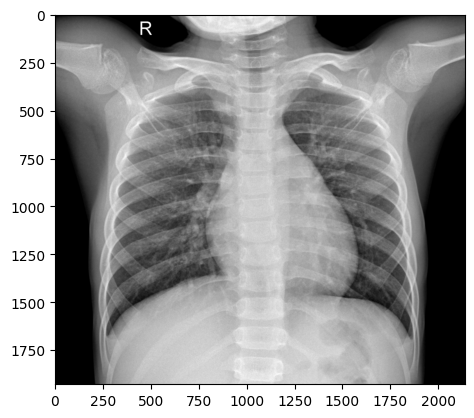

In [ ]:
# converting the images into grayscale
for i in CATEGORIES:
    path=os.path.join(DataDir,i)
    for img in os.listdir(path):
        img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
        plt.imshow(img_array,cmap='gray')
        plt.show()
        break
    break

In [ ]:
# intializing the size of the image so that every image should be in same dimension
img_size=100

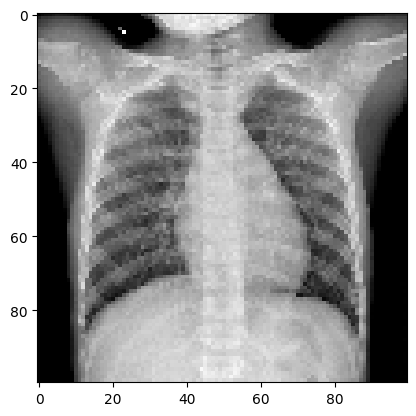

In [ ]:
# image after resize and gray scale
new_array=cv2.resize(img_array,(img_size,img_size))
plt.imshow(new_array,cmap='gray')
plt.show()

In [ ]:
training_data=[]

In [ ]:
# defining the function for training data according to the categories converting the images into gray scale with resizing the image into 100 x 100
# converting it into numpy arrays
def create_training_data():
    for i in CATEGORIES:

        path=os.path.join(DataDir,i)
        class_num=CATEGORIES.index(i)

        for img in os.listdir(path):
            try:
                img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
                new_array=cv2.resize(img_array,(img_size,img_size))
                training_data.append([new_array,class_num])

            except Exception as e:
                pass

In [ ]:
create_training_data()

In [ ]:
print(len(training_data))

5226


In [ ]:
import random
random.shuffle(training_data)
for sample in training_data[:10]:
    print(sample)

[array([[  2,   2,   1, ..., 114, 155, 166],
       [  2,   2,   1, ..., 157, 155, 151],
       [  4,   2,   2, ..., 157, 157, 122],
       ...,
       [  2,   1,   1, ...,   2,   2,   2],
       [  1,   1,   1, ...,   2,   2,   2],
       [  1,   1,   1, ...,   2,   2,   2]], dtype=uint8), 1]
[array([[ 41,  40, 254, ...,  45,  49,  53],
       [ 36,  40, 255, ...,  52,  50,  55],
       [ 33,  34, 254, ...,  58,  62,  71],
       ...,
       [ 18,  33,  79, ...,   0,   0,   0],
       [ 18,  38,  88, ...,   0,   0,   0],
       [ 19,  41,  84, ...,   0,   0,   0]], dtype=uint8), 1]
[array([[ 21,  19,  30, ...,  20,  18,  17],
       [ 53, 193,  24, ...,  17,  16,  12],
       [189, 196, 108, ...,  11,  12,  13],
       ...,
       [  3,  44,  53, ...,   3,  14,  14],
       [  4,  44,  51, ...,   2,  11,  14],
       [  4,  45,  51, ...,   0,  13,  14]], dtype=uint8), 1]
[array([[ 0,  0,  0, ..., 54, 42, 30],
       [ 0,  0,  0, ..., 55, 43, 27],
       [ 0,  0,  0, ..., 55, 43, 22],


In [ ]:
X=[]
y=[]

In [ ]:
# spliting the features and labels
for features,label in training_data:
    X.append(features)
    y.append(label)

In [ ]:
print(X[0].reshape(-1,img_size,img_size,1))

[[[[  2]
   [  2]
   [  1]
   ...
   [114]
   [155]
   [166]]

  [[  2]
   [  2]
   [  1]
   ...
   [157]
   [155]
   [151]]

  [[  4]
   [  2]
   [  2]
   ...
   [157]
   [157]
   [122]]

  ...

  [[  2]
   [  1]
   [  1]
   ...
   [  2]
   [  2]
   [  2]]

  [[  1]
   [  1]
   [  1]
   ...
   [  2]
   [  2]
   [  2]]

  [[  1]
   [  1]
   [  1]
   ...
   [  2]
   [  2]
   [  2]]]]


In [ ]:
y = np.array(y)

In [ ]:
# reshapping the features for making it compatible with tensorflow
X = np.array(X).reshape(-1,img_size,img_size,1)

In [ ]:
# as we do for training data similiarly doing with validation data
validation_data=[]
DataDir_val= r"/content/drive/MyDrive/Data Science and AI Notebooks/Deep Learning/files used in DL/val"

In [ ]:
def create_validating_data():
    for i in CATEGORIES:

        path=os.path.join(DataDir_val,i)
        class_num=CATEGORIES.index(i)

        for img in os.listdir(path):
            try:
                img_array=cv2.imread(os.path.join(path,img),cv2.IMREAD_GRAYSCALE)
                new_array=cv2.resize(img_array,(img_size,img_size))
                validation_data.append([new_array,class_num])

            except Exception as e:
                pass

In [ ]:
create_validating_data()
print(len(validation_data))

16


In [ ]:
import random
random.shuffle(validation_data)
for sample in validation_data[:10]:
    print(sample)

[array([[  0,   8,  24, ...,  65,  61, 103],
       [  0,   3,  23, ...,  67,  59, 121],
       [  1,   0,  18, ...,  61,  58, 123],
       ...,
       [  2,   2,   2, ...,   1,   2,   2],
       [  2,   2,   2, ...,   1,   2,   2],
       [  2,   2,   2, ...,   1,   2,   2]], dtype=uint8), 1]
[array([[  2, 107,  75, ...,   0,   3,  10],
       [ 59, 105,  51, ...,   2,   0,  21],
       [122,  96,  15, ...,  11,   8,  35],
       ...,
       [  0,   0,  18, ...,   0,   0,   0],
       [  0,   0,  13, ...,   0,   0,   0],
       [  2,   0,  11, ...,   0,   0,   0]], dtype=uint8), 0]
[array([[64, 63, 64, ..., 97, 93, 93],
       [51, 52, 50, ..., 90, 92, 90],
       [39, 41, 44, ..., 96, 86, 86],
       ...,
       [16, 51, 78, ...,  2,  2,  6],
       [28, 56, 80, ...,  2,  1,  8],
       [35, 61, 87, ...,  2, 10,  7]], dtype=uint8), 1]
[array([[  0,  85, 102, ...,  95,  73,  51],
       [ 50,  77,  90, ...,  83,  60,  39],
       [ 44,  62,  95, ...,  76,  55,  34],
       ...,
      

In [ ]:
X_val=[]
y_val=[]

In [ ]:
for features,label in validation_data:
    X_val.append(features)
    y_val.append(label)

In [ ]:
y_val = np.array(y_val)
X_val=np.array(X_val).reshape(-1,img_size,img_size,1)

In [ ]:
# importing the library for training the model and adding the neural network layers
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense,Dropout,Activation,Flatten, Conv2D,MaxPooling2D
import pickle

In [ ]:
# Pixels value ranges from 0 to 255, 0 means black, 255 means white....
# In order to scale it down to a scale of 0 to 1, we are performing this step
X = X/255.0
x_val = X_val/255.0

In [ ]:
X.shape

(5226, 100, 100, 1)

In [ ]:
x_val.shape

(16, 100, 100, 1)

In [ ]:
# intializing the neural network layer for training the model
model= Sequential()

model.add(Conv2D(64,(3,3),input_shape=X.shape[1:]))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Conv2D(128,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Conv2D(256,(3,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Flatten())
model.add(Dense(64))

model.add(Dropout(.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 98, 98, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 47, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 21, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,638,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,008,193 (7.66 MB)

 Trainable params: 2,008,193 (7.66 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [ ]:
# fittting the model with 10 epochs and using the validation data we have created
model.fit(X,y,batch_size=4,epochs=10,validation_data=(x_val, y_val))

Epoch 1/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 331s 251ms/step - accuracy: 0.8997 - loss: 0.2594 - val_accuracy: 0.6875 - val_loss: 0.5434
Epoch 2/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 372s 244ms/step - accuracy: 0.9497 - loss: 0.1403 - val_accuracy: 0.9375 - val_loss: 0.1850
Epoch 3/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 325s 249ms/step - accuracy: 0.9598 - loss: 0.1097 - val_accuracy: 1.0000 - val_loss: 0.0614
Epoch 4/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 321s 245ms/step - accuracy: 0.9631 - loss: 0.1002 - val_accuracy: 0.9375 - val_loss: 0.1327
Epoch 5/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 328s 250ms/step - accuracy: 0.9642 - loss: 0.0924 - val_accuracy: 1.0000 - val_loss: 0.0891
Epoch 6/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 320s 245ms/step - accuracy: 0.9696 - loss: 0.0817 - val_accuracy: 1.0000 - val_loss: 0.0336
Epoch 7/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 321s 245ms/step - accuracy: 0.9723 - loss: 0.0829 - val_accuracy: 1.0000 - val_loss: 0.0328
Epoch 8/10
1307/1307 ━━━━━━━━━━━━━━━━━━━━ 322s 244ms/step - ac

In [ ]:
# saving the model
model.save(r'/content/drive/MyDrive/Data Science and AI Notebooks/Deep Learning/files used in DL/model_10.h5')

In [ ]:
# importing the library for testing the model
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tensorflow.keras.models import load_model

In [ ]:
CATEGORIES = ["NORMAL", "PNEUMONIA"]

In [ ]:
# function for preparing the image for predicting the class
def prepare(image):
    img_size=100
    #img_array=cv2.imread(image,cv2.IMREAD_GRAYSCALE)
    img=tf.keras.preprocessing.image.load_img(image, color_mode='grayscale', target_size=(img_size,img_size))
    new_array=tf.keras.preprocessing.image.img_to_array(img)

    return new_array.reshape(-1,img_size,img_size,1)

In [ ]:
model = tf.keras.models.load_model('/content/drive/MyDrive/Data Science and AI Notebooks/Deep Learning/files used in DL/model_10.h5')

In [ ]:
image = r'/content/drive/MyDrive/Data Science and AI Notebooks/Deep Learning/files used in DL/test/NORMAL/IM-0059-0001.jpeg'

In [ ]:
prediction=model.predict([prepare(image)/255.0])
print(prediction)
print(round(prediction[0][0]))
print(CATEGORIES[int(round(prediction[0][0]))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
[[0.01907938]]
0
NORMAL


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=('Tensor(shape=(1, 100, 100, 1))',)
  warnings.warn(msg)


In [ ]:
image2 = r'/content/drive/MyDrive/Data Science and AI Notebooks/Deep Learning/files used in DL/test/PNEUMONIA/person1_virus_6.jpeg'

In [ ]:
prediction=model.predict([prepare(image2)/255.0])
print(prediction)
print(round(prediction[0][0]))
print(CATEGORIES[int(round(prediction[0][0]))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
[[0.99999136]]
1
PNEUMONIA


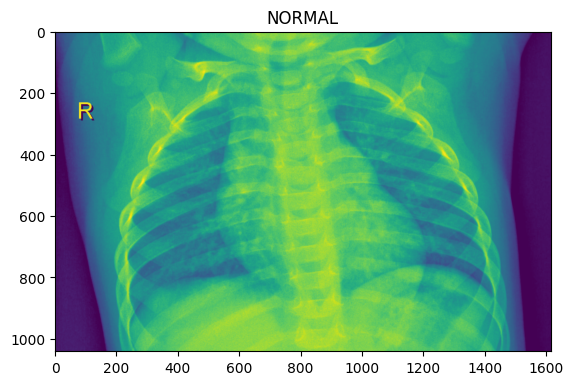

In [ ]:
img=mpimg.imread(image)
imgplot=plt.imshow(img)
plt.title(CATEGORIES[int(prediction[0][0])])
plt.show()

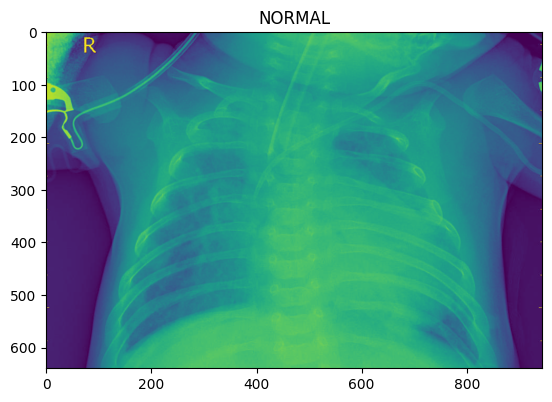

In [ ]:
img=mpimg.imread(image2)
imgplot=plt.imshow(img)
plt.title(CATEGORIES[int(prediction[0][0])])
plt.show()